# DATASCI 207 • Volatility Dataset — Data Wrangling + EDA

**Notebook:** `data_wrangler_020426.ipynb`  
**Last updated:** 4/18/2026

## Goal
Create a **model-ready ETF panel** from the provided volatility dataset exports (CSV/XLSX), with:

- One row per **ETF** per **trading date**
- Clean unique key: **(ticker, date)**
- Macro/risk series transformed from long → wide and **left-joined by date**
- Quality checks to ensure no leakage / no duplicate keys / sensible missingness
- Clean outputs written to `data/clean/`

## Inputs
- CSV: `3c3b4b03-7e47-4929-9551-4d6a5edd33d7.csv`
- XLSX: `8ce8cde8-6608-4cb5-a945-638033f95789.xlsx`
- Dataset description PDF: `be3f053b-ba3d-458d-8e6c-2c8b27be8943.pdf`

## Dataset facts
- ~116,525 rows × 18 columns
- 36 ETFs + 6 macro/risk series tickers (42 total)
- Date range: 2014-12-31 to 2025-12-31 (trading days)
- Macro tickers: `US_3M_TB_YLD`, `US_10Y_BOND_YLD`, `US_10Y_3M_YLD_SPREAD`, `NYGOLDS`, `OIL_WTI_S`, `VIX`

---

## 1. Setup

In [ ]:
# data wrangler for volatility panel
# numpy/pandas/matplotlib
# display options widened to 200 cols because the panel is 44+ features wide

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)


In [ ]:
# Mount My Drive:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. SETUP

In [ ]:
# update DATA_PATH_CSV if Drive folder path differs
# MACRO_TICKERS lists every non-ETF row in the long table;
# these get pivoted to columns and joined onto the ETF panel

DATA_PATH_CSV = r"/content/drive/MyDrive/Colab Notebooks/volatility_dataset_013026.csv"
DATA_PATH_XLSX = r"/content/drive/MyDrive/Colab Notebooks/volatility_dataset_013026.xlsx"

# Choose which input to use
USE_INPUT = "csv"   # "csv" or "xlsx"

# Key columns (natural primary key)
KEY_COLS = ["ticker", "date"]
DATE_COL = "date"
TARGET_COL = "forward_vol_5d_annual_decimel_calculated"

# Macro/risk series tickers (stored as rows in the same long table; values live in adj_close)
MACRO_TICKERS = [
    "US_3M_TB_YLD",
    "US_10Y_BOND_YLD",
    "US_10Y_3M_YLD_SPREAD",
    "NYGOLDS",
    "OIL_WTI_S",
    "VIX",
]

# Output location
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/data/clean"
OUTPUT_STEM = "vol_panel_model_ready"

# EDA sampling
EDA_SAMPLE_TICKER = "SPY"


## 3. Load raw data

In [ ]:
# Create output folder first, then load whichever raw file was selected in CONFIG
# fail fast on unknown USE_INPUT to catch typos before they cause silent wrong-file loads

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

if USE_INPUT.lower() == "csv":
    df_raw = pd.read_csv(DATA_PATH_CSV)
elif USE_INPUT.lower() == "xlsx":
    df_raw = pd.read_excel(DATA_PATH_XLSX)
else:
    raise ValueError("USE_INPUT must be 'csv' or 'xlsx'")

print("Loaded:", USE_INPUT)
print("Shape:", df_raw.shape)
df_raw.head()


Loaded: csv
Shape: (116525, 18)


/tmp/ipython-input-1200865836.py:12: DtypeWarning: Columns (14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_PATH_CSV)


,date,ticker,adj_close,has_price,volume_k,volume,trailing_vol_daily_pct_5d_factset,trailing_vol_daily_pct_20d_factset,trailing_vol_annual_decimel_5d_factset,trailing_vol_annual_decimel_20d_factset,trailing_vol__annual_decimel_5d_calculated,trailing_vol__annual_decimel_20d_calculated,forward_vol_5d__annual_decimel_calculated,group_type,market,sector,industry,daily_log_return
0,12/31/2025,SPY,681.92,1.0,74144.80,74144800.0,0.7149,0.6093,0.1135,0.0967,0.0646,0.0861,NaN,market,sp500,NaN,NaN,-0.007436
1,12/30/2025,SPY,687.01,1.0,47160.67,47160670.0,0.5891,0.6001,0.0935,0.0953,0.0535,0.0816,NaN,market,sp500,NaN,NaN,-0.001222
2,12/29/2025,SPY,687.85,1.0,62559.50,62559500.0,0.5340,0.6257,0.0848,0.0993,0.0625,0.0834,NaN,market,sp500,NaN,NaN,-0.003570
3,12/26/2025,SPY,690.31,1.0,41613.35,41613350.0,0.4783,0.6453,0.0759,0.1024,0.0409,0.0839,NaN,market,sp500,NaN,NaN,-0.000101
4,12/24/2025,SPY,690.38,1.0,39445.56,39445560.0,0.4640,0.6800,0.0737,0.1080,0.0248,0.0866,NaN,market,sp500,NaN,NaN,0.003511


## 4. Standardize column names

In [ ]:
# Column name normalization -- FactSet exports have mixed casing and spaces
# which breaks downstream merges and feature references; fix once here

import re

def standardize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")

df = df_raw.copy()
df.columns = [standardize_column_name(c) for c in df.columns]

print("Columns:", df.columns.to_list())


Columns: ['date', 'ticker', 'adj_close', 'has_price', 'volume_k', 'volume', 'trailing_vol_daily_pct_5d_factset', 'trailing_vol_daily_pct_20d_factset', 'trailing_vol_annual_decimel_5d_factset', 'trailing_vol_annual_decimel_20d_factset', 'trailing_vol_annual_decimel_5d_calculated', 'trailing_vol_annual_decimel_20d_calculated', 'forward_vol_5d_annual_decimel_calculated', 'group_type', 'market', 'sector', 'industry', 'daily_log_return']


## 5. Parse dates (mixed formats safe)

In [ ]:
# Two-pass date parse: 4-digit year first, then fill misses with 2-digit year
# safer than one loose parse because FactSet exports mix both formats in the same column
# unparseable dates get dropped here before the macro pivot

dt1 = pd.to_datetime(df[DATE_COL], format="%m/%d/%Y", errors="coerce")
dt2 = pd.to_datetime(df[DATE_COL], format="%m/%d/%y", errors="coerce")
df[DATE_COL] = dt1.fillna(dt2)

failed = df[DATE_COL].isna().sum()
print("Failed date parses:", failed)
print("Date range:", df[DATE_COL].min(), "to", df[DATE_COL].max())

# Optional: drop rows with unparseable dates
if failed > 0:
    df = df.dropna(subset=[DATE_COL]).copy()
    print("After dropping failed dates, shape:", df.shape)


Failed date parses: 0
Date range: 2014-12-31 00:00:00 to 2025-12-31 00:00:00


## 6. Quick QC: keys, duplicates, missingness

In [ ]:
# QC before the macro pivot -- catch duplicate keys and high missingness early
# rather than letting them silently propagate into the modeling dataset

dup_count = df.duplicated(subset=KEY_COLS).sum()
print("Duplicate (ticker, date) rows:", dup_count)

missing = df.isna().mean().sort_values(ascending=False)
print("\nMissingness (top 15):")
display((missing.head(15) * 100).to_frame("missing_percent"))

print("\nDtypes:")
display(df.dtypes)


Duplicate (ticker, date) rows: 0

Missingness (top 15):


,missing_percent
market,97.625402
sector,69.131088
industry,47.758850
trailing_vol_annual_decimel_20d_calculated,17.781592
forward_vol_5d_annual_decimel_calculated,17.318172
trailing_vol_annual_decimel_5d_calculated,17.318172
daily_log_return,17.194593
trailing_vol_daily_pct_20d_factset,17.194593
trailing_vol_annual_decimel_20d_factset,17.194593
volume,17.163699



Dtypes:


,0
date,datetime64[ns]
ticker,object
adj_close,float64
has_price,float64
volume_k,float64
volume,float64
trailing_vol_daily_pct_5d_factset,float64
trailing_vol_daily_pct_20d_factset,float64
trailing_vol_annual_decimel_5d_factset,float64
trailing_vol_annual_decimel_20d_factset,float64


## 7. Split ETFs vs Macro series

In [ ]:
# Macro rows live under the special macro tickers; everything else is ETF panel data
# Macro values are stored in adj_close column in the long table, not in their own columns

df["ticker"] = df["ticker"].astype(str)

df_macro_long = df[df["ticker"].isin(MACRO_TICKERS)].copy()
df_etf_long = df[~df["ticker"].isin(MACRO_TICKERS)].copy()

print("ETF rows:", df_etf_long.shape)
print("Macro rows:", df_macro_long.shape)

print("\nMacro tickers present:", sorted(df_macro_long["ticker"].unique().tolist()))


ETF rows: (102482, 18)
Macro rows: (14043, 18)

Macro tickers present: ['NYGOLDS', 'OIL_WTI_S', 'US_10Y_BOND_YLD', 'US_3M_TB_YLD', 'VIX']


## 8. Macro: long → wide and join onto ETFs by date

In [ ]:
# Pivot macro from long to wide so each date gets one row of macro values,
# then left-join onto the ETF panel -- left join keeps the ETF rows as backbone
# Forward-fill gaps because rates and VIX can be sparse on some trading dates
# sort before ffill -- ffill on an unsorted index bleeds values across dates

# Step 1: pivot
macro_wide = (
    df_macro_long
    .pivot_table(index=DATE_COL, columns="ticker", values="adj_close", aggfunc="first")
    .sort_index()
)

# Step 2: forward-fill
macro_wide = macro_wide.ffill()

print("macro_wide shape:", macro_wide.shape)
display(macro_wide.tail(5))

# Step 3: join
df_etf_long = df_etf_long.sort_values(["ticker", DATE_COL]).copy()
df_panel = df_etf_long.merge(macro_wide, how="left", left_on=DATE_COL, right_index=True)

print("df_panel shape:", df_panel.shape)
df_panel.head()


macro_wide shape: (2871, 5)


ticker,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX
date,,,,,
2025-12-25,4479.42,58.72,4.13,3.64,13.47
2025-12-26,4533.21,56.60,4.13,3.63,13.60
2025-12-29,4332.56,57.89,4.11,3.62,14.20
2025-12-30,4339.40,57.79,4.13,3.60,14.33
2025-12-31,4322.61,57.26,4.17,3.63,14.95


df_panel shape: (102482, 23)


,date,ticker,adj_close,has_price,volume_k,volume,trailing_vol_daily_pct_5d_factset,trailing_vol_daily_pct_20d_factset,trailing_vol_annual_decimel_5d_factset,trailing_vol_annual_decimel_20d_factset,trailing_vol_annual_decimel_5d_calculated,trailing_vol_annual_decimel_20d_calculated,forward_vol_5d_annual_decimel_calculated,group_type,market,sector,industry,daily_log_return,NYGOLDS,OIL_WTI_S,US_10Y_BOND_YLD,US_3M_TB_YLD,VIX
63639,2014-12-31,BEDZ,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1182.9,53.49,2.19,0.02,19.20
63638,2015-01-02,BEDZ,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1189.8,52.57,2.11,0.03,17.79
63637,2015-01-05,BEDZ,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1205.1,50.03,2.03,0.03,19.92
63636,2015-01-06,BEDZ,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1219.3,48.02,1.94,0.03,21.12
63635,2015-01-07,BEDZ,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,industry,NaN,NaN,hotels_resorts_cruise_lines,NaN,1211.1,48.70,1.97,0.03,19.31


## 9. Enforce modeling filters (has_price, target not-null)

In [ ]:
# Keep only rows where has_price == 1 (per dataset description)
# I filter only on columns that really define whether a row is usable for modeling
# Don't drop null-target rows here -- the last 5 trading days per ticker
# will always have null forward vol by construction, and we still need those rows
# for y_known_at_t as a feature in downstream modeling notebooks

df_panel["has_price"] = pd.to_numeric(df_panel.get("has_price", 1), errors="coerce")

df_model = df_panel.copy()

# Filter has_price if column exists
if "has_price" in df_model.columns:
    df_model = df_model[df_model["has_price"] == 1].copy()

print("After has_price filter:", df_model.shape)

# Report target missingness (do not drop by default; tail rows per ticker will be missing)
if TARGET_COL in df_model.columns:
    tgt_missing = df_model[TARGET_COL].isna().mean()
    print("Target missing rate:", round(float(tgt_missing), 4))
else:
    print("WARNING: TARGET_COL not found in columns.")


After has_price filter: (96525, 23)
Target missing rate: 0.0019


## 10. Key QC checks (no duplicates, monotone dates within ticker)

In [ ]:
# Final panel integrity checks: unique keys, sorted dates inside each ticker,
# and a return spot-check as a leakage guard --
# if daily_log_return was shifted incorrectly, the median abs diff will be non-trivial

dup_count = df_model.duplicated(subset=KEY_COLS).sum()
print("Duplicate keys in df_model:", dup_count)

# monotone increasing check
bad = 0
for tkr, g in df_model.groupby("ticker"):
    d = g[DATE_COL]
    if not d.is_monotonic_increasing:
        bad += 1
        if bad <= 5:
            print("Non-monotone dates for ticker:", tkr)

print("Tickers with non-monotone dates:", bad)

# Spot-check: daily_log_return sanity for sample ticker
if "adj_close" in df_model.columns and "daily_log_return" in df_model.columns:
    sample = df_model[df_model["ticker"] == EDA_SAMPLE_TICKER].sort_values(DATE_COL).copy()
    # recompute returns from adj_close
    recomputed = np.log(sample["adj_close"]).diff()
    diff_abs = (recomputed - sample["daily_log_return"]).abs()
    print("Return check (median abs diff):", float(diff_abs.median(skipna=True)))
    print("Return check (max abs diff):", float(diff_abs.max(skipna=True)))
else:
    print("Skipping return spot-check (missing columns).")


Duplicate keys in df_model: 0
Tickers with non-monotone dates: 0
Return check (median abs diff): 2.5422055346252526e-10
Return check (max abs diff): 2.7679655563378393e-05


## 11. Lightweight EDA (sanity plots)

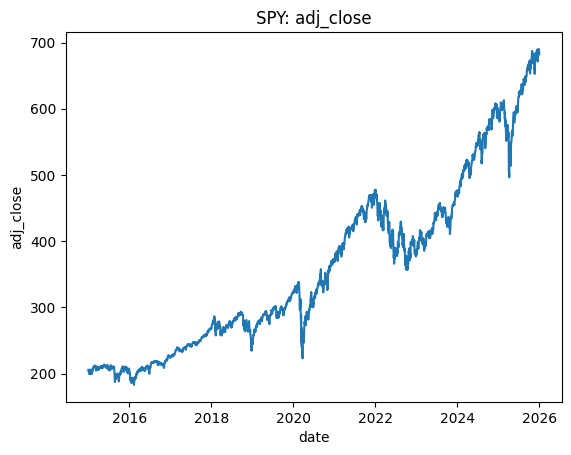

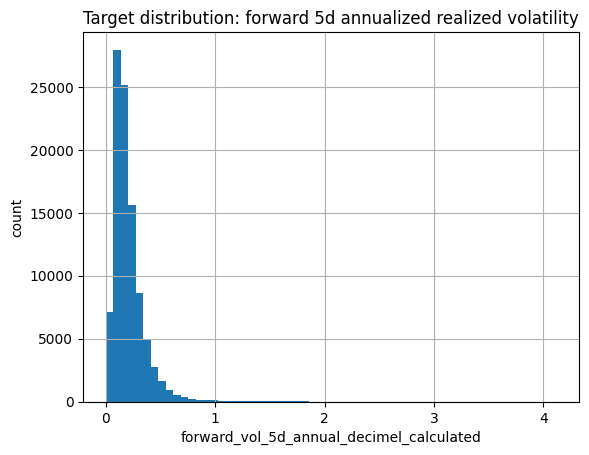

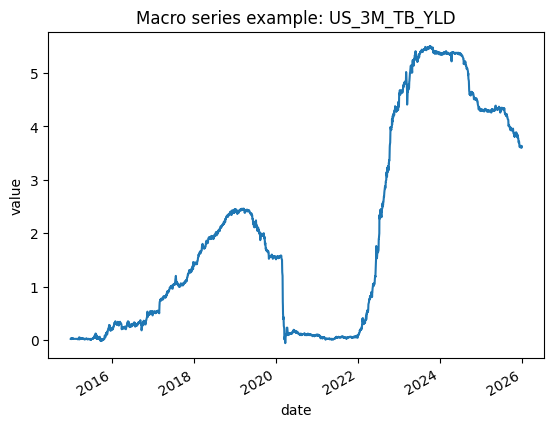

In [ ]:
# Lightweight EDA
# Heavy EDA lives in the separate EDA notebook

sample = df_model[df_model["ticker"] == EDA_SAMPLE_TICKER].sort_values(DATE_COL).copy()

# Price over time
if "adj_close" in sample.columns:
    plt.figure()
    plt.plot(sample[DATE_COL], sample["adj_close"])
    plt.title(f"{EDA_SAMPLE_TICKER}: adj_close")
    plt.xlabel("date")
    plt.ylabel("adj_close")
    plt.show()

# Target distribution
if TARGET_COL in df_model.columns:
    plt.figure()
    df_model[TARGET_COL].dropna().hist(bins=60)
    plt.title("Target distribution: forward 5d annualized realized volatility")
    plt.xlabel(TARGET_COL)
    plt.ylabel("count")
    plt.show()

# Macro series quick look
macro_cols = [c for c in MACRO_TICKERS if c in df_model.columns]
if macro_cols:
    plt.figure()
    df_model.sort_values(DATE_COL).groupby(DATE_COL)[macro_cols[0]].mean().plot()
    plt.title(f"Macro series example: {macro_cols[0]}")
    plt.xlabel("date")
    plt.ylabel("value")
    plt.show()


## 12. Save clean outputs

In [ ]:
# Write model-ready panel to Drive
# Parquet preferred
# CSV as fallback

out_parquet = os.path.join(OUTPUT_DIR, f"{OUTPUT_STEM}.parquet")
out_csv = os.path.join(OUTPUT_DIR, f"{OUTPUT_STEM}.csv")

# Write Parquet if available
try:
    df_model.to_parquet(out_parquet, index=False)
    print("Wrote:", out_parquet)
except Exception as e:
    print("Parquet write failed (install pyarrow). Error:", e)

df_model.to_csv(out_csv, index=False)
print("Wrote:", out_csv)

print("Final df_model shape:", df_model.shape)


Wrote: /content/drive/MyDrive/Colab Notebooks/data/clean/vol_panel_model_ready.parquet
Wrote: /content/drive/MyDrive/Colab Notebooks/data/clean/vol_panel_model_ready.csv
Final df_model shape: (96525, 23)
